# Article 1 — RQ1 and RQ2 evidence

This is the only active, read-only analysis notebook. It uses canonical CSVs and immutable caches, stops on any integrity failure, and never recalculates or modifies experimental results. RQ1 compares expertise routing with FedDF; RQ2 fixes EXPERT routing and compares logit- with probability-space aggregation. ORACLE is an informed-sample reference, not a student upper bound.

## 1. Scope and definitions

Primary analyses use T=8. The RQ2 sensitivity is CIFAR-10 only, for IID, α=0.1 and Single at T=1,4,8. All RQ1 figures use one ordered categorical heterogeneity axis: IID → α=1.0 → α=0.5 → α=0.1 → Multi → Single. Uniform spacing is categorical and does not assert equal quantitative intervals.

Validated repository root: /home/roi/PycharmProjects/KD_v5


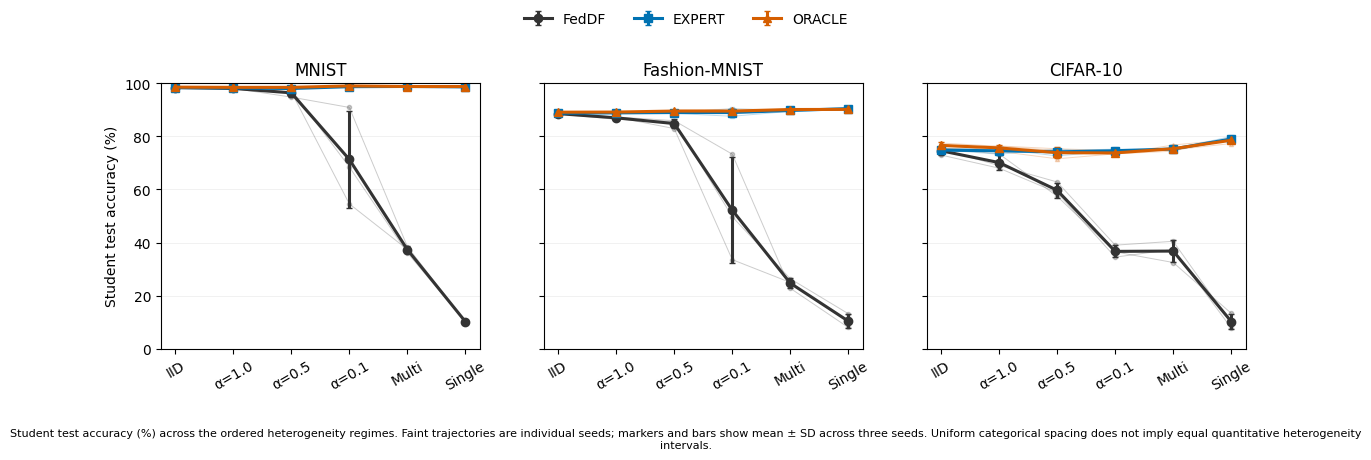

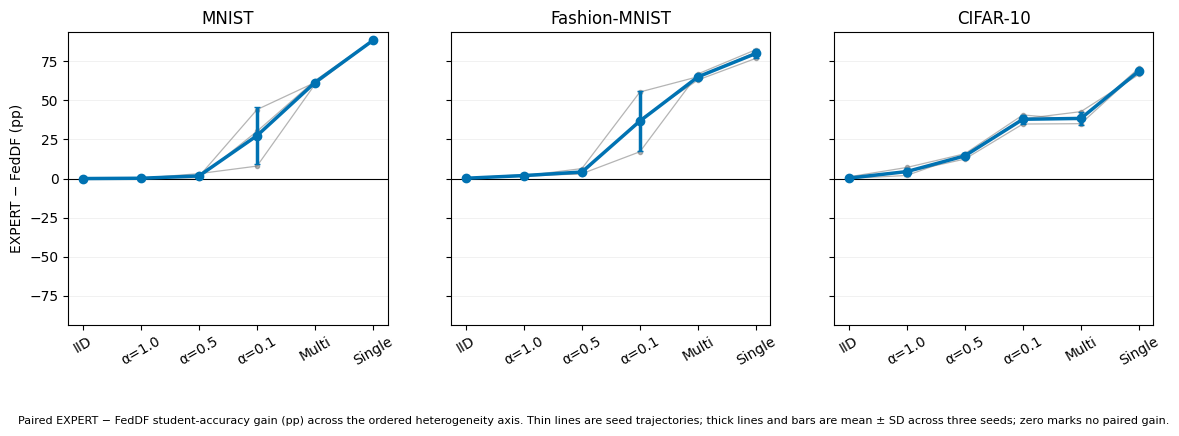

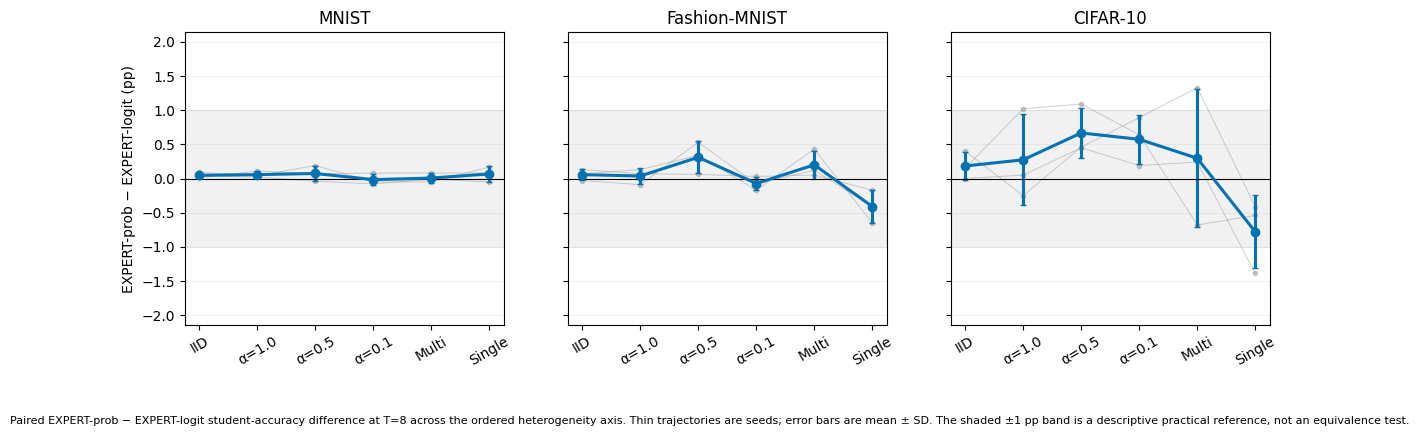

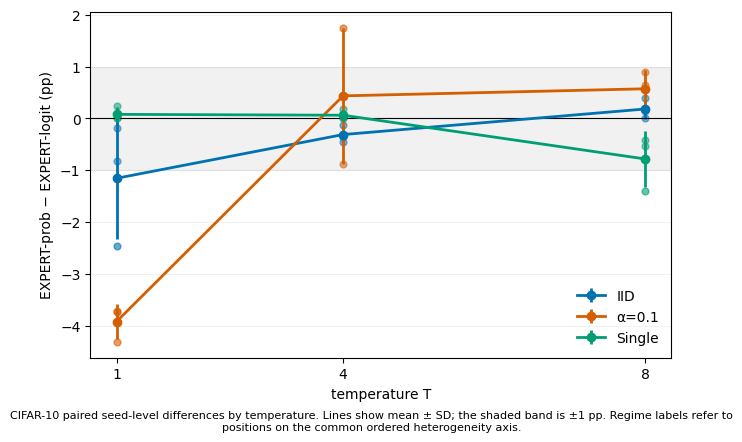

In [1]:
import os
import sys
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

os.environ.setdefault("MPLCONFIGDIR", "/tmp/article1-mpl")
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "OUTPUTS" / "article1" / "results.csv").is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
OUT = ROOT / "OUTPUTS" / "article1"

from article1.audit import audit
from article1.rq2 import validate_cells

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from article1.audit import audit
from article1.rq2 import validate_cells

DATASETS = ("mnist", "fmnist", "cifar")
HETEROGENEITY = ("iid", "alpha1p0", "alpha0p5", "alpha0p1", "multi", "single")
RQ2_REGIMES = ("iid", "alpha0p1", "single")
SEEDS = (42, 43, 44)
CRN = ("cache_sha256", "M_sha256", "proxy_sha256", "student_init_sha256", "batch_order_sha256", "updates")
EXPERT_ROUTING = ("fallback_rate", "mean_selected_teachers")
DATASET_LABEL = {"mnist": "MNIST", "fmnist": "Fashion-MNIST", "cifar": "CIFAR-10"}
REGIME_LABEL = {"iid": "IID", "alpha1p0": "α=1.0", "alpha0p5": "α=0.5", "alpha0p1": "α=0.1", "multi": "Multi", "single": "Single"}
COLORS = {"FedDF": "#333333", "EXPERT": "#0072B2", "ORACLE": "#D55E00", "IID": "#0072B2", "α=0.1": "#D55E00", "Single": "#009E73"}


def _root(root: Path | None = None) -> Path:
    if root is not None: return Path(root)
    return next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "OUTPUTS" / "article1" / "results.csv").is_file())


def _finite(frame: pd.DataFrame, columns: list[str], label: str) -> None:
    if not np.isfinite(frame[columns].to_numpy(float)).all():
        raise RuntimeError(f"{label} has missing or non-finite metrics")


def _summary(frame: pd.DataFrame, groups: list[str], value: str) -> pd.DataFrame:
    return frame.groupby(groups, observed=True)[value].agg(mean="mean", sd=lambda x: x.std(ddof=1), n="count", minimum="min", maximum="max").reset_index()


def _paired(frame: pd.DataFrame, left: str, right: str, *, keys: list[str], metrics: list[str], paired_fields: tuple[str, ...] = CRN + EXPERT_ROUTING) -> pd.DataFrame:
    a = frame.loc[frame.method.eq(left), keys + metrics + list(paired_fields)].copy()
    b = frame.loc[frame.method.eq(right), keys + metrics + list(paired_fields)].copy()
    if a.duplicated(keys).any() or b.duplicated(keys).any():
        raise RuntimeError(f"duplicate rows in {left}/{right} pairing")
    joined = a.merge(b, on=keys, suffixes=("_left", "_right"), validate="one_to_one")
    unequal = [field for field in paired_fields if not joined[f"{field}_left"].eq(joined[f"{field}_right"]).all()]
    if unequal: raise RuntimeError(f"CRN mismatch for {left}/{right}: {unequal}")
    for metric in metrics:
        joined[f"delta_{metric}"] = joined[f"{metric}_left"] - joined[f"{metric}_right"]
    return joined


def load_and_validate(root: Path | None = None) -> dict:
    root = _root(root); out = root / "OUTPUTS" / "article1"
    main_path, rq2_path, conditions_path = out / "results.csv", out / "results_rq2_temperature.csv", out / "conditions.csv"
    main, new_rq2, conditions = pd.read_csv(main_path), pd.read_csv(rq2_path), pd.read_csv(conditions_path)
    required = {"dataset", "regime", "seed", "method", "temperature", "student_test_accuracy", "student_test_nll", "target_accuracy", "target_nll", "target_entropy", *CRN}
    if required - set(main) or required - set(new_rq2): raise RuntimeError("results CSV lacks the required canonical schema")
    t8 = main.loc[main.temperature.eq(8.0)].copy()
    if len(t8) != 486: raise RuntimeError(f"main T=8 grid has {len(t8)} rows, expected 486")
    if t8.duplicated(["dataset", "regime", "seed", "method", "temperature"]).any(): raise RuntimeError("duplicate main T=8 identity")
    if len(conditions) != 54 or conditions.duplicated(["dataset", "regime", "seed"]).any(): raise RuntimeError("conditions CSV must contain 54 unique conditions")
    _finite(t8, ["student_test_accuracy", "student_test_nll", "target_accuracy", "target_nll", "target_entropy", "fallback_rate", "mean_selected_teachers"], "main T=8")
    expert_t8 = _paired(t8, "expert_prob", "expert_logit", keys=["dataset", "regime", "seed"], metrics=["student_test_accuracy", "student_test_nll", "target_accuracy", "target_nll", "target_entropy"])
    if len(expert_t8) != 54: raise RuntimeError("expected 54 complete EXPERT pairs at T=8")
    # Full cache-level validation establishes immutable-cache correspondence and
    # reconstructs all 486 T=8 targets, including EXPERT routing/fallbacks.
    integrity = audit(main_path, source_root=out / "sources")
    if not integrity["ok"]: raise RuntimeError(f"main cache audit failed: {integrity['issues']}")
    rq2 = validate_cells([main_path, rq2_path], source_root=out / "sources", temperatures=(1.0, 4.0, 8.0), reject_foreign=rq2_path)
    if not rq2["ok"] or rq2["counts"].get("valid_reusable") != 54:
        raise RuntimeError(f"RQ2 temperature integrity failed: {rq2}")
    temp = pd.concat([main, new_rq2], ignore_index=True)
    temp = temp.loc[(temp.dataset.eq("cifar")) & temp.regime.isin(RQ2_REGIMES) & temp.seed.isin(SEEDS) & temp.method.isin(("expert_logit", "expert_prob")) & temp.temperature.isin((1.0, 4.0, 8.0))].copy()
    if len(temp) != 54 or temp.duplicated(["dataset", "regime", "seed", "method", "temperature"]).any(): raise RuntimeError("RQ2 sensitivity must contain 54 unique rows")
    _finite(temp, ["student_test_accuracy", "student_test_nll", "target_accuracy", "target_nll", "target_entropy", "fallback_rate", "mean_selected_teachers"], "RQ2 sensitivity")
    return {"root": root, "out": out, "t8": t8, "conditions": conditions, "expert_t8": expert_t8, "temperature": temp, "integrity": integrity, "rq2_integrity": rq2}


def _pp_summary(frame: pd.DataFrame, groups: list[str], value: str) -> pd.DataFrame:
    rows = []
    for key, values in frame.groupby(groups, observed=True)[value]:
        key = key if isinstance(key, tuple) else (key,)
        v = values.to_numpy(float); absolute = np.abs(v)
        rows.append(dict(zip(groups, key), mean_pp=float(v.mean()), sd_pp=float(v.std(ddof=1)) if len(v) > 1 else np.nan,
                         mae_pp=float(absolute.mean()), median_abs_pp=float(np.median(absolute)), max_abs_pp=float(absolute.max()),
                         within_0_5pp=int((absolute <= .5).sum()), within_1pp=int((absolute <= 1).sum()), n=int(len(v)),
                         positives=int((v > 0).sum()), negatives=int((v < 0).sum()), ties=int((v == 0).sum())))
    return pd.DataFrame(rows)


def rq1_tables(context: dict) -> dict[str, pd.DataFrame]:
    t8 = context["t8"]; keys = ["dataset", "regime", "seed"]
    gain = _paired(t8, "expert_logit", "feddf_logit", keys=keys, metrics=["student_test_accuracy"], paired_fields=CRN)
    gain["expert_minus_feddf_pp"] = 100 * gain.pop("delta_student_test_accuracy")
    trajectory = []
    for (dataset, seed), rows in gain.groupby(["dataset", "seed"], observed=True):
        values = rows.set_index("regime").loc[list(HETEROGENEITY), "expert_minus_feddf_pp"].to_numpy()
        changes = np.diff(values)
        trajectory.append({"dataset": dataset, "seed": seed, "nondecreasing": bool(np.all(changes >= 0)),
                           "decreasing_transitions": json.dumps([f"{HETEROGENEITY[i]}→{HETEROGENEITY[i + 1]}" for i, delta in enumerate(changes) if delta < 0]),
                           **{f"delta_{regime}_pp": value for regime, value in zip(HETEROGENEITY, values)}})
    effects = gain.copy()
    effect_summary = _summary(gain, ["dataset", "regime"], "expert_minus_feddf_pp").rename(columns={"mean": "mean_pp", "sd": "sd_pp", "minimum": "min_pp", "maximum": "max_pp"})
    effect_summary["positive_seeds"] = effect_summary.apply(lambda r: int((gain.loc[(gain.dataset == r.dataset) & (gain.regime == r.regime), "expert_minus_feddf_pp"] > 0).sum()), axis=1)
    oracle = _paired(t8, "oracle_logit", "expert_logit", keys=keys, metrics=["student_test_accuracy"], paired_fields=CRN)
    oracle["oracle_minus_expert_pp"] = 100 * oracle.pop("delta_student_test_accuracy")
    oracle["abs_gap_pp"] = oracle.oracle_minus_expert_pp.abs()
    gap_rows = []
    for name, values in [("overall", oracle.oracle_minus_expert_pp), *[((f"{dataset}/{regime}"), group.oracle_minus_expert_pp) for (dataset, regime), group in oracle.groupby(["dataset", "regime"], observed=True)]]:
        a = values.abs(); gap_rows.append({"scope": name, "mean_signed_pp": values.mean(), "mae_pp": a.mean(), "median_abs_pp": a.median(), "max_abs_pp": a.max(), "within_1pp": int((a <= 1).sum()), "expert_exceeds_oracle": int((values < 0).sum()), "n": len(values)})
    accuracy = _summary(t8.loc[t8.method.isin(("feddf_logit", "expert_logit", "oracle_logit"))], ["dataset", "regime", "method"], "student_test_accuracy")
    controls = _summary(t8.loc[t8.method.isin(("feddf_logit", "confidence_logit", "consensus_logit", "energy_logit", "expert_logit", "oracle_logit"))], ["dataset", "regime", "method"], "student_test_accuracy")
    control_pairs = []
    for control in ("confidence_logit", "consensus_logit", "energy_logit"):
        comparison = _paired(t8, "expert_logit", control, keys=keys, metrics=["student_test_accuracy"], paired_fields=CRN)
        comparison["control"] = control
        comparison["expert_minus_control_pp"] = 100 * comparison.pop("delta_student_test_accuracy")
        control_pairs.append(comparison[[*keys, "control", "expert_minus_control_pp"]])
    return {"accuracy": accuracy, "effects": effects, "effects_summary": effect_summary, "trajectory": pd.DataFrame(trajectory), "oracle_gap": pd.DataFrame(gap_rows), "controls": controls, "control_pairs": pd.concat(control_pairs, ignore_index=True), "gain_seed": gain}


def rq2_tables(context: dict) -> dict[str, pd.DataFrame]:
    t8 = context["t8"]; keys = ["dataset", "regime", "seed"]
    metrics = ["student_test_accuracy", "student_test_nll", "target_accuracy", "target_nll", "target_entropy"]
    paired = _paired(t8, "expert_prob", "expert_logit", keys=keys, metrics=metrics)
    paired["space_delta_pp"] = 100 * paired.pop("delta_student_test_accuracy")
    paired = paired.rename(columns={"delta_student_test_nll": "delta_student_nll", "delta_target_accuracy": "delta_target_accuracy", "delta_target_nll": "delta_target_nll", "delta_target_entropy": "delta_target_entropy"})
    condition_summary = _pp_summary(paired, ["dataset", "regime"], "space_delta_pp")
    global_summary = _pp_summary(paired.assign(scope="overall"), ["scope"], "space_delta_pp")
    oracle = _paired(t8, "oracle_prob", "oracle_logit", keys=keys, metrics=metrics)
    oracle["space_delta_pp"] = 100 * oracle.pop("delta_student_test_accuracy")
    oracle_summary = _pp_summary(oracle.assign(scope="overall"), ["scope"], "space_delta_pp")
    temp = context["temperature"]
    temp_pairs = _paired(temp, "expert_prob", "expert_logit", keys=["dataset", "regime", "seed", "temperature"], metrics=metrics)
    temp_pairs["space_delta_pp"] = 100 * temp_pairs.pop("delta_student_test_accuracy")
    temp_pairs = temp_pairs.rename(columns={"delta_student_test_nll": "delta_student_nll", "delta_target_accuracy": "delta_target_accuracy", "delta_target_nll": "delta_target_nll", "delta_target_entropy": "delta_target_entropy"})
    temp_summary = _pp_summary(temp_pairs, ["regime", "temperature"], "space_delta_pp")
    temp_summary["seed_values_pp"] = temp_summary.apply(lambda r: json.dumps(temp_pairs.loc[(temp_pairs.regime == r.regime) & (temp_pairs.temperature == r.temperature), "space_delta_pp"].tolist()), axis=1)
    return {"paired": paired, "condition_summary": condition_summary, "global_summary": global_summary, "oracle": oracle_summary, "temperature_paired": temp_pairs, "temperature_summary": temp_summary}


def _caption(fig, caption: str) -> None:
    fig.text(.5, .005, caption, ha="center", va="bottom", fontsize=8, wrap=True)


def figures(context: dict, rq1: dict, rq2: dict) -> dict[str, object]:
    rendered = {}
    t8, gain, paired, temp = context["t8"], rq1["gain_seed"], rq2["paired"], rq2["temperature_paired"]
    x = np.arange(len(HETEROGENEITY)); labels = [REGIME_LABEL[r] for r in HETEROGENEITY]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True, constrained_layout=False)
    method_styles = (("feddf_logit", "FedDF", "o"), ("expert_logit", "EXPERT", "s"), ("oracle_logit", "ORACLE", "^") )
    legend_handles = []
    for ax, dataset in zip(axes, DATASETS):
        d = t8[(t8.dataset == dataset) & t8.method.isin([item[0] for item in method_styles])]
        for method, label, marker in method_styles:
            rows = d[d.method == method]
            for _, seed_rows in rows.groupby("seed"):
                values = seed_rows.set_index("regime").loc[list(HETEROGENEITY), "student_test_accuracy"]
                ax.plot(x, 100 * values, color=COLORS[label], lw=.7, alpha=.25, marker=marker, ms=3)
            stats = rows.groupby("regime").student_test_accuracy.agg(["mean", "std"]).loc[list(HETEROGENEITY)]
            handle = ax.errorbar(x, 100 * stats["mean"], yerr=100 * stats["std"], color=COLORS[label], lw=2.2, marker=marker, capsize=2, label=label)
            if dataset == DATASETS[0]: legend_handles.append(handle)
        ax.set_title(DATASET_LABEL[dataset]); ax.set_xticks(x, labels, rotation=30); ax.set_ylim(0, 100); ax.grid(axis="y", alpha=.25)
    axes[0].set_ylabel("Student test accuracy (%)"); fig.legend(legend_handles, ["FedDF", "EXPERT", "ORACLE"], loc="upper center", ncol=3, frameon=False); fig.subplots_adjust(top=.82, bottom=.23)
    _caption(fig, "Student test accuracy (%) across the ordered heterogeneity regimes. Faint trajectories are individual seeds; markers and bars show mean ± SD across three seeds. Uniform categorical spacing does not imply equal quantitative heterogeneity intervals."); rendered["rq1_student_accuracy"] = fig
    gain_values = gain.expert_minus_feddf_pp.to_numpy(); gain_limit = max(abs(gain_values.min()), abs(gain_values.max())) + 5
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True, constrained_layout=False)
    for ax, dataset in zip(axes, DATASETS):
        d = gain[gain.dataset == dataset]
        for _, rows in d.groupby("seed"):
            y = rows.set_index("regime").loc[list(HETEROGENEITY), "expert_minus_feddf_pp"]; ax.plot(x, y, color="#777777", lw=.9, alpha=.55, marker="o", ms=3)
        stats = d.groupby("regime").expert_minus_feddf_pp.agg(["mean", "std"]).loc[list(HETEROGENEITY)]
        ax.errorbar(x, stats["mean"], yerr=stats["std"], color=COLORS["EXPERT"], lw=2.5, marker="o", capsize=2)
        ax.axhline(0, color="black", lw=.8); ax.set_title(DATASET_LABEL[dataset]); ax.set_xticks(x, labels, rotation=30); ax.set_ylim(-gain_limit, gain_limit); ax.grid(axis="y", alpha=.25)
    axes[0].set_ylabel("EXPERT − FedDF (pp)"); fig.subplots_adjust(bottom=.23)
    _caption(fig, "Paired EXPERT − FedDF student-accuracy gain (pp) across the ordered heterogeneity axis. Thin lines are seed trajectories; thick lines and bars are mean ± SD across three seeds; zero marks no paired gain."); rendered["rq1_expertise_gain"] = fig
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True, constrained_layout=False)
    for ax, dataset in zip(axes, DATASETS):
        d = paired[paired.dataset == dataset]
        for seed, rows in d.groupby("seed"):
            y = rows.set_index("regime").loc[list(HETEROGENEITY), "space_delta_pp"]; ax.plot(x, y, color="#777777", lw=.7, alpha=.35, marker="o", ms=3)
        stats = d.groupby("regime").space_delta_pp.agg(["mean", "std"]).loc[list(HETEROGENEITY)]
        ax.errorbar(x, stats["mean"], yerr=stats["std"], color=COLORS["EXPERT"], lw=2.2, marker="o", capsize=2)
        ax.axhspan(-1, 1, color="#BBBBBB", alpha=.2); ax.axhline(0, color="black", lw=.8)
        ax.set_xticks(x, labels, rotation=30); ax.set_title(DATASET_LABEL[dataset]); ax.grid(axis="y", alpha=.25)
    span = max(abs(paired.space_delta_pp).max(), 1.0) + .75
    for ax in axes: ax.set_ylim(-span, span)
    axes[0].set_ylabel("EXPERT-prob − EXPERT-logit (pp)"); fig.subplots_adjust(bottom=.23)
    _caption(fig, "Paired EXPERT-prob − EXPERT-logit student-accuracy difference at T=8 across the ordered heterogeneity axis. Thin trajectories are seeds; error bars are mean ± SD. The shaded ±1 pp band is a descriptive practical reference, not an equivalence test."); rendered["rq2_logit_probability_t8"] = fig
    fig, ax = plt.subplots(figsize=(7.5, 4.8)); temperatures = [1., 4., 8.]
    for regime, label in (("iid", "IID"), ("alpha0p1", "α=0.1"), ("single", "Single")):
        d = temp[temp.regime == regime]; stats = d.groupby("temperature").space_delta_pp.agg(["mean", "std"]).loc[temperatures]
        ax.errorbar(temperatures, stats["mean"], yerr=stats["std"], marker="o", lw=2, color=COLORS[label], label=label)
        for seed, rows in d.groupby("seed"): ax.scatter(rows.temperature, rows.space_delta_pp, color=COLORS[label], s=24, alpha=.6)
    ax.axhspan(-1, 1, color="#BBBBBB", alpha=.2); ax.axhline(0, color="black", lw=.8); ax.set_xticks(temperatures); ax.set_xlabel("temperature T"); ax.set_ylabel("EXPERT-prob − EXPERT-logit (pp)"); ax.legend(frameon=False); ax.grid(axis="y", alpha=.25)
    fig.subplots_adjust(bottom=.16); _caption(fig, "CIFAR-10 paired seed-level differences by temperature. Lines show mean ± SD; the shaded band is ±1 pp. Regime labels refer to positions on the common ordered heterogeneity axis."); rendered["rq2_temperature_sensitivity"] = fig
    return rendered


def claims(context: dict, rq1: dict, rq2: dict) -> str:
    trajectory = rq1["trajectory"]; gain = rq1["gain_seed"]; gap = rq1["oracle_gap"].query("scope == 'overall'").iloc[0]
    t8 = rq2["global_summary"].iloc[0]; temp = rq2["temperature_summary"]
    low_t = temp.loc[temp.temperature.eq(1.0), "mean_pp"].abs().max()
    return f"""# RQ1/RQ2 claim–evidence ledger

## RQ1 — Need for expertise

### Observación

En {int(trajectory.nondecreasing.sum())}/{len(trajectory)} trayectorias dataset–seed del eje completo IID→α=1.0→α=0.5→α=0.1→multi→single, EXPERT−FedDF es no decreciente. Las excepciones se registran explícitamente en `table_rq1_trajectory.csv`; la tendencia media aumenta a través del eje. El gap ORACLE−EXPERT medio firmado es {gap.mean_signed_pp:.3f} pp (MAE {gap.mae_pp:.3f} pp).

### Interpretación

El patrón es compatible con que el routing por expertise sea más útil cuando la especialización de clase hace menos apropiado promediar a todos los teachers. ORACLE es una referencia informada por muestra para contextualizar el routing, no un techo del estudiante.

### Claim defendible

En este protocolo, la ventaja de EXPERT sobre FedDF aumenta de forma descriptiva a través de los regímenes ordenados de heterogeneidad, aunque una trayectoria individual puede presentar una excepción local.

### Lo que no demuestra

No demuestra causalidad únicamente desde accuracy, ni que EXPERT reproduzca ORACLE, ni que las separaciones categóricas uniformes del eje correspondan a incrementos cuantitativos idénticos de heterogeneidad.

## RQ2 — Logits frente a probabilidades

### Observación

A T=8, EXPERT-prob−EXPERT-logit tiene media {t8.mean_pp:.3f} pp, SD {t8.sd_pp:.3f} pp, MAE {t8.mae_pp:.3f} pp y {int(t8.within_1pp)}/{int(t8.n)} condiciones dentro de ±1 pp. En CIFAR a T=1, el mayor valor absoluto de la media por régimen es {low_t:.3f} pp.

### Interpretación

Con routing EXPERT idéntico, el espacio de agregación tiene un efecto práctico pequeño en conjunto a T=8, pero la sensibilidad CIFAR muestra que esa similitud no se extiende automáticamente a temperaturas bajas.

### Claim defendible

Bajo la receta canónica T=8, logits y probabilidades producen resultados de estudiante mayoritariamente cercanos, pero la robustez frente a temperatura es limitada: el efecto depende del régimen y puede ser material a T=1.

### Lo que no demuestra

No demuestra equivalencia matemática entre operadores, invarianza fuera de T=1,4,8, ni una temperatura óptima. El control ORACLE a T=8 es secundario y no convierte ORACLE en un upper bound del estudiante.

## Ledger

| claim | evidence | figure/table | status | limitation |
|---|---|---|---|---|
| Expertise gain increases across the ordered heterogeneity axis | {int(trajectory.nondecreasing.sum())}/{len(trajectory)} nondecreasing seed trajectories | fig_rq1_expertise_gain; table_rq1_paired_effects | qualified | One local trajectory exception; descriptive, three seeds, protocol-specific |
| EXPERT is close to ORACLE in every condition | Oracle gap has max absolute {gap.max_abs_pp:.3f} pp | table_rq1_oracle_gap | unsupported | Do not use in narrative; gaps remain condition-dependent |
| Aggregation space is practically limited at T=8 | {int(t8.within_1pp)}/{int(t8.n)} within ±1 pp, MAE {t8.mae_pp:.3f} pp | fig_rq2_logit_probability_t8; table_rq2_t8_summary | qualified | Some condition-level effects exceed ±1 pp |
| T=8 similarity is temperature-invariant | CIFAR T=1 has up to {low_t:.3f} pp mean absolute regime effect | fig_rq2_temperature_sensitivity; table_rq2_temperature_summary | unsupported | Do not use in narrative |
"""


# Execute the complete read-only analysis in the notebook namespace.
context = load_and_validate(ROOT)
rq1 = rq1_tables(context)
rq2 = rq2_tables(context)
notebook_figures = figures(context, rq1, rq2)
ledger = claims(context, rq1, rq2)
report = {
    "integrity": {"main_audit": context["integrity"], "rq2": context["rq2_integrity"]},
    "rq1": rq1,
    "rq2": rq2,
    "figures": notebook_figures,
    "ledger": ledger,
}

print(f"Validated repository root: {ROOT}")


## 2. Load and integrity

The analysis requires 486 primary T=8 rows, 54 T=8 EXPERT pairs, and 27 CIFAR RQ2 pairs over temperature. Cache hashes, CRN, routing/fallback equality and target normalization are checked before any table or figure is exported.

In [2]:
integrity = report["integrity"]
display(pd.DataFrame([{
    "main_audit_ok": integrity["main_audit"]["ok"],
    "main_T8_rows": integrity["main_audit"]["primary_rows"],
    "reconstructed_targets": integrity["main_audit"]["target_sanity"]["targets_checked"],
    "rq2_valid_cells": integrity["rq2"]["counts"].get("valid_reusable", 0),
    "rq2_pair_issues": len(integrity["rq2"]["pair_issues"]),
    "rq2_foreign_rows": len(integrity["rq2"]["foreign_rows"]),
}]))


,main_audit_ok,main_T8_rows,reconstructed_targets,rq2_valid_cells,rq2_pair_issues,rq2_foreign_rows
0,True,486,486,54,0,0


## 3. RQ1 — Need for expertise

The ordered heterogeneity trajectory reports paired EXPERT−FedDF accuracy deltas in pp across all six regimes. The ORACLE gap is descriptive distance to an informed routing reference.

,dataset,regime,seed,expert_minus_feddf_pp
0,mnist,iid,42,-0.06
1,mnist,alpha1p0,42,0.15
2,mnist,alpha0p5,42,3.11
3,mnist,alpha0p1,42,7.93
4,mnist,multi,42,60.25
5,mnist,single,42,88.23
6,mnist,iid,43,-0.01
7,mnist,alpha1p0,43,0.09
8,mnist,alpha0p5,43,1.29
9,mnist,alpha0p1,43,44.09


,dataset,regime,mean_pp,sd_pp,n,min_pp,max_pp,positive_seeds
0,cifar,alpha0p1,37.906667,2.915344,3,34.86,40.67,3
1,cifar,alpha0p5,14.480000,1.806682,3,12.43,15.84,3
2,cifar,alpha1p0,4.430000,2.568287,3,1.94,7.07,3
3,cifar,iid,0.256667,0.715006,3,-0.31,1.06,2
4,cifar,multi,38.453333,3.944241,3,35.08,42.79,3
5,cifar,single,68.743333,2.063549,3,66.58,70.69,3
6,fmnist,alpha0p1,36.770000,19.142024,3,17.12,55.36,3
7,fmnist,alpha0p5,4.153333,1.911134,3,3.03,6.36,3
8,fmnist,alpha1p0,1.866667,0.585349,3,1.39,2.52,3
9,fmnist,iid,0.166667,0.041633,3,0.12,0.20,3


,dataset,seed,nondecreasing,decreasing_transitions,delta_iid_pp,delta_alpha1p0_pp,delta_alpha0p5_pp,delta_alpha0p1_pp,delta_multi_pp,delta_single_pp
0,cifar,42,False,"[""alpha0p1\u2192multi""]",1.06,7.07,15.84,40.67,37.49,70.69
1,cifar,43,True,[],0.02,1.94,15.17,38.19,42.79,66.58
2,cifar,44,True,[],-0.31,4.28,12.43,34.86,35.08,68.96
3,fmnist,42,True,[],0.12,1.69,6.36,55.36,65.13,80.75
4,fmnist,43,True,[],0.20,2.52,3.03,37.83,63.05,76.90
5,fmnist,44,True,[],0.18,1.39,3.07,17.12,66.94,82.47
6,mnist,42,True,[],-0.06,0.15,3.11,7.93,60.25,88.23
7,mnist,43,True,[],-0.01,0.09,1.29,44.09,61.42,88.42
8,mnist,44,True,[],-0.03,0.23,0.49,30.18,62.61,88.59


,scope,mean_signed_pp,mae_pp,median_abs_pp,max_abs_pp,within_1pp,expert_exceeds_oracle,n
0,overall,0.249815,0.573519,0.41,2.98,44,17,54
1,cifar/alpha0p1,-0.823333,0.823333,0.64,1.26,2,3,3
2,cifar/alpha0p5,-0.326667,0.780000,0.68,1.06,2,2,3
3,cifar/alpha1p0,1.103333,1.750000,1.30,2.98,1,1,3
4,cifar/iid,1.770000,1.770000,1.59,2.55,0,0,3
5,cifar/multi,0.113333,0.686667,0.85,1.20,2,2,3
6,cifar/single,-0.483333,0.590000,0.41,1.20,2,2,3
7,fmnist/alpha0p1,0.546667,0.660000,0.47,1.34,2,1,3
8,fmnist/alpha0p5,0.560000,0.573333,0.83,0.87,3,1,3
9,fmnist/alpha1p0,0.313333,0.313333,0.26,0.48,3,0,3


,dataset,regime,method,mean,sd,n,minimum,maximum
0,cifar,alpha0p1,confidence_logit,0.383100,0.026564,3,0.3550,0.4078
1,cifar,alpha0p1,consensus_logit,0.565700,0.045746,3,0.5352,0.6183
2,cifar,alpha0p1,energy_logit,0.484767,0.046460,3,0.4350,0.5270
3,cifar,alpha0p1,expert_logit,0.745800,0.006557,3,0.7388,0.7518
4,cifar,alpha0p1,feddf_logit,0.366733,0.022606,3,0.3451,0.3902
5,cifar,alpha0p1,oracle_logit,0.737567,0.007445,3,0.7324,0.7461
6,cifar,alpha0p5,confidence_logit,0.609167,0.022060,3,0.5942,0.6345
7,cifar,alpha0p5,consensus_logit,0.663167,0.020295,3,0.6437,0.6842
8,cifar,alpha0p5,energy_logit,0.661133,0.024373,3,0.6453,0.6892
9,cifar,alpha0p5,expert_logit,0.741633,0.013857,3,0.7260,0.7524


,dataset,regime,seed,control,expert_minus_control_pp
0,mnist,iid,42,confidence_logit,-0.08
1,mnist,alpha1p0,42,confidence_logit,0.04
2,mnist,alpha0p5,42,confidence_logit,2.78
3,mnist,alpha0p1,42,confidence_logit,7.15
4,mnist,multi,42,confidence_logit,58.59
5,mnist,single,42,confidence_logit,88.23
6,mnist,iid,43,confidence_logit,0.03
7,mnist,alpha1p0,43,confidence_logit,0.06
8,mnist,alpha0p5,43,confidence_logit,1.11
9,mnist,alpha0p1,43,confidence_logit,38.31


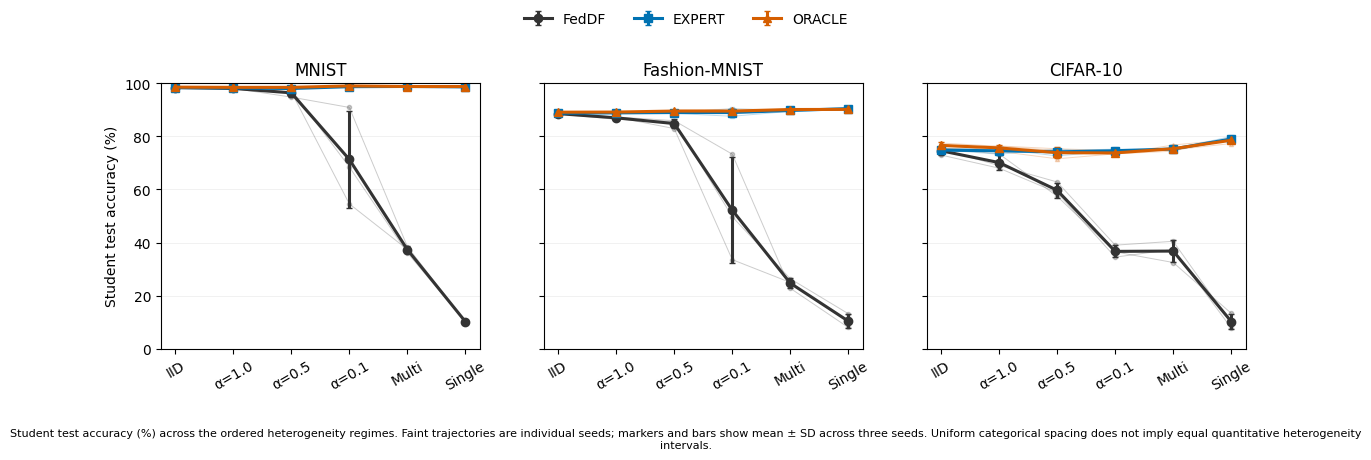

**Figure RQ1-A.** Student test accuracy (%) for FedDF, EXPERT and the informed-sample ORACLE reference across the ordered categorical heterogeneity regimes. Faint trajectories are seeds; markers and bars are mean ± SD across three seeds.

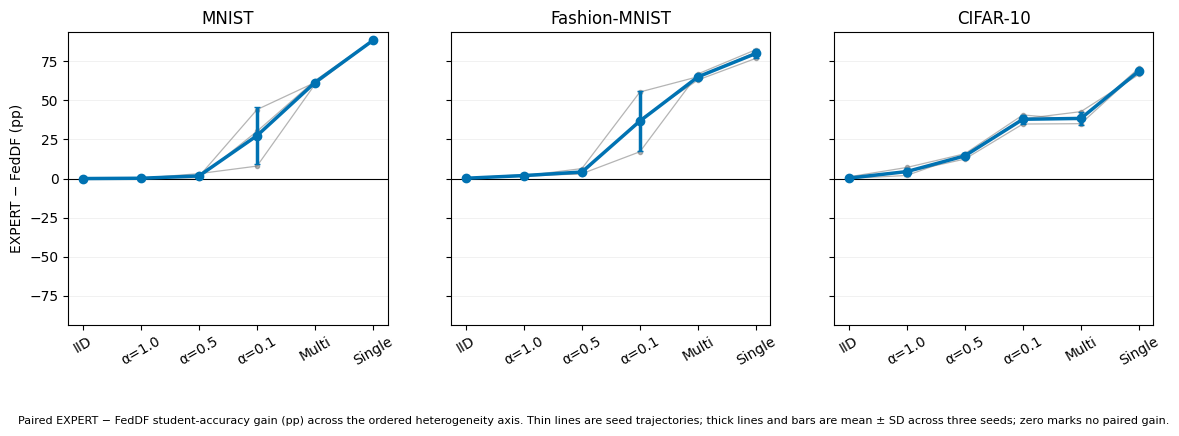

**Figure RQ1-B.** Paired EXPERT − FedDF student-accuracy gain in percentage points. Thin trajectories are individual seeds; thick estimates and error bars are mean ± SD across three seeds; zero denotes no paired gain.

In [3]:
display(rq1["effects"][["dataset", "regime", "seed", "expert_minus_feddf_pp"]])
display(rq1["effects_summary"])
display(rq1["trajectory"])
display(rq1["oracle_gap"])
display(rq1["controls"].head(18))
display(rq1["control_pairs"].head(18))
display(notebook_figures["rq1_student_accuracy"])
display(Markdown("**Figure RQ1-A.** Student test accuracy (%) for FedDF, EXPERT and the informed-sample ORACLE reference across the ordered categorical heterogeneity regimes. Faint trajectories are seeds; markers and bars are mean ± SD across three seeds."))
display(notebook_figures["rq1_expertise_gain"])
display(Markdown("**Figure RQ1-B.** Paired EXPERT − FedDF student-accuracy gain in percentage points. Thin trajectories are individual seeds; thick estimates and error bars are mean ± SD across three seeds; zero denotes no paired gain."))


## 4. RQ2 — Logits versus probabilities

All comparisons retain identical EXPERT routing. The T=8 result is primary; the ORACLE aggregation-space comparison is a secondary control only.

,dataset,regime,mean_pp,sd_pp,mae_pp,median_abs_pp,max_abs_pp,within_0_5pp,within_1pp,n,positives,negatives,ties
0,cifar,alpha0p1,0.573333,0.354730,0.573333,0.64,0.89,1,3,3,3,0,0
1,cifar,alpha0p5,0.666667,0.366652,0.666667,0.46,1.09,2,2,3,3,0,0
2,cifar,alpha1p0,0.273333,0.663802,0.440000,0.25,1.02,2,2,3,2,1,0
3,cifar,iid,0.183333,0.202073,0.183333,0.15,0.40,3,3,3,2,0,1
4,cifar,multi,0.296667,1.006197,0.750000,0.68,1.33,1,2,3,2,1,0
5,cifar,single,-0.780000,0.532259,0.780000,0.54,1.39,1,2,3,0,3,0
6,fmnist,alpha0p1,-0.073333,0.100167,0.093333,0.08,0.17,3,3,3,1,2,0
7,fmnist,alpha0p5,0.310000,0.236432,0.310000,0.34,0.53,2,3,3,3,0,0
8,fmnist,alpha1p0,0.036667,0.113725,0.096667,0.09,0.13,3,3,3,2,1,0
9,fmnist,iid,0.056667,0.080829,0.076667,0.07,0.13,3,3,3,2,1,0


,scope,mean_pp,sd_pp,mae_pp,median_abs_pp,max_abs_pp,within_0_5pp,within_1pp,n,positives,negatives,ties
0,overall,0.087037,0.430847,0.277778,0.125,1.39,44,50,54,35,18,1


,scope,mean_pp,sd_pp,mae_pp,median_abs_pp,max_abs_pp,within_0_5pp,within_1pp,n,positives,negatives,ties
0,overall,0.100926,0.462721,0.320185,0.185,1.39,41,50,54,27,24,3


,regime,temperature,mean_pp,sd_pp,seed_values_pp,mae_pp,max_abs_pp,within_1pp,n
0,alpha0p1,1.0,-3.916667,0.340783,"[-3.710000000000002, -3.73, -4.309999999999992]",3.916667,4.31,0,3
1,alpha0p1,4.0,0.436667,1.315003,"[0.44000000000000705, 1.749999999999996, -0.88...",1.023333,1.75,2,3
2,alpha0p1,8.0,0.573333,0.354730,"[0.6399999999999961, 0.8900000000000019, 0.190...",0.573333,0.89,3,3
3,iid,1.0,-1.153333,1.175982,"[-0.8199999999999985, -0.18000000000000238, -2...",1.153333,2.46,2,3
4,iid,4.0,-0.310000,0.173494,"[-0.11999999999999789, -0.45999999999999375, -...",0.310000,0.46,3,3
5,iid,8.0,0.183333,0.202073,"[0.15000000000000568, 0.40000000000000036, 0.0]",0.183333,0.40,3,3
6,single,1.0,0.080000,0.138564,"[0.24000000000000687, 0.0, 0.0]",0.080000,0.24,3,3
7,single,4.0,0.063333,0.109697,"[0.19000000000000128, 0.0, 0.0]",0.063333,0.19,3,3
8,single,8.0,-0.780000,0.532259,"[-0.5400000000000071, -0.40999999999999925, -1...",0.780000,1.39,2,3


,regime,temperature,seed,space_delta_pp
0,iid,8.0,42,0.15
1,alpha0p1,8.0,42,0.64
2,single,8.0,42,-0.54
3,iid,8.0,43,0.40
4,alpha0p1,8.0,43,0.89
5,single,8.0,43,-0.41
6,iid,8.0,44,0.00
7,alpha0p1,8.0,44,0.19
8,single,8.0,44,-1.39
9,iid,1.0,42,-0.82


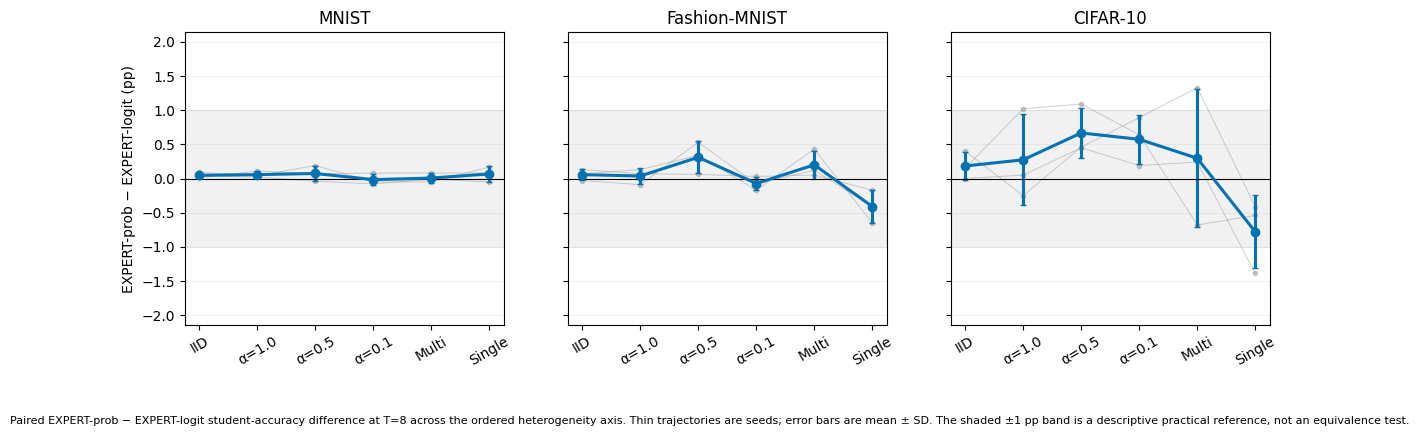

**Figure RQ2-A.** Paired EXPERT-prob − EXPERT-logit student-accuracy difference at T=8, in percentage points. The grey band is the descriptive ±1 pp practical reference, not a significance or equivalence test.

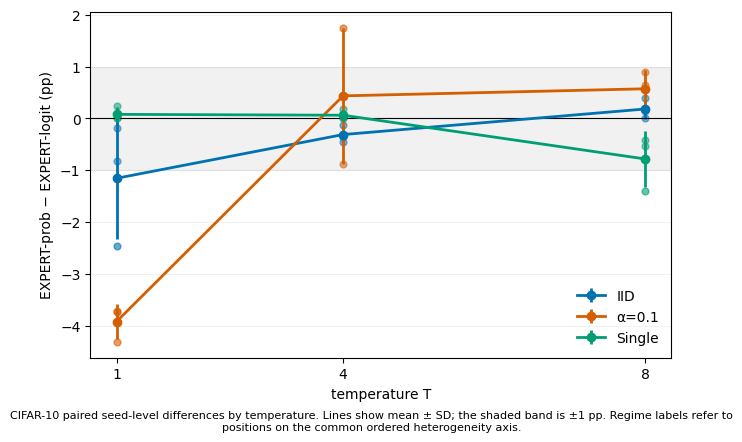

**Figure RQ2-B.** CIFAR-10 paired EXPERT-prob − EXPERT-logit student-accuracy difference by temperature. Coloured series identify regime; individual points are seeds and bars are mean ± SD.

In [4]:
display(rq2["condition_summary"])
display(rq2["global_summary"])
display(rq2["oracle"])
temperature_summary = rq2["temperature_summary"]
temperature_paired = rq2["temperature_paired"]
display(temperature_summary[["regime", "temperature", "mean_pp", "sd_pp", "seed_values_pp", "mae_pp", "max_abs_pp", "within_1pp", "n"]])
display(temperature_paired[["regime", "temperature", "seed", "space_delta_pp"]])
display(notebook_figures["rq2_logit_probability_t8"])
display(Markdown("**Figure RQ2-A.** Paired EXPERT-prob − EXPERT-logit student-accuracy difference at T=8, in percentage points. The grey band is the descriptive ±1 pp practical reference, not a significance or equivalence test."))
display(notebook_figures["rq2_temperature_sensitivity"])
display(Markdown("**Figure RQ2-B.** CIFAR-10 paired EXPERT-prob − EXPERT-logit student-accuracy difference by temperature. Coloured series identify regime; individual points are seeds and bars are mean ± SD."))


## 5. Claim–evidence ledger

Claims are limited to descriptive evidence. The ±1 pp band is a practical reference, not a significance or equivalence test.

In [5]:
display(Markdown(ledger))


# RQ1/RQ2 claim–evidence ledger

## RQ1 — Need for expertise

### Observación

En 8/9 trayectorias dataset–seed del eje completo IID→α=1.0→α=0.5→α=0.1→multi→single, EXPERT−FedDF es no decreciente. Las excepciones se registran explícitamente en `table_rq1_trajectory.csv`; la tendencia media aumenta a través del eje. El gap ORACLE−EXPERT medio firmado es 0.250 pp (MAE 0.574 pp).

### Interpretación

El patrón es compatible con que el routing por expertise sea más útil cuando la especialización de clase hace menos apropiado promediar a todos los teachers. ORACLE es una referencia informada por muestra para contextualizar el routing, no un techo del estudiante.

### Claim defendible

En este protocolo, la ventaja de EXPERT sobre FedDF aumenta de forma descriptiva a través de los regímenes ordenados de heterogeneidad, aunque una trayectoria individual puede presentar una excepción local.

### Lo que no demuestra

No demuestra causalidad únicamente desde accuracy, ni que EXPERT reproduzca ORACLE, ni que las separaciones categóricas uniformes del eje correspondan a incrementos cuantitativos idénticos de heterogeneidad.

## RQ2 — Logits frente a probabilidades

### Observación

A T=8, EXPERT-prob−EXPERT-logit tiene media 0.087 pp, SD 0.431 pp, MAE 0.278 pp y 50/54 condiciones dentro de ±1 pp. En CIFAR a T=1, el mayor valor absoluto de la media por régimen es 3.917 pp.

### Interpretación

Con routing EXPERT idéntico, el espacio de agregación tiene un efecto práctico pequeño en conjunto a T=8, pero la sensibilidad CIFAR muestra que esa similitud no se extiende automáticamente a temperaturas bajas.

### Claim defendible

Bajo la receta canónica T=8, logits y probabilidades producen resultados de estudiante mayoritariamente cercanos, pero la robustez frente a temperatura es limitada: el efecto depende del régimen y puede ser material a T=1.

### Lo que no demuestra

No demuestra equivalencia matemática entre operadores, invarianza fuera de T=1,4,8, ni una temperatura óptima. El control ORACLE a T=8 es secundario y no convierte ORACLE en un upper bound del estudiante.

## Ledger

| claim | evidence | figure/table | status | limitation |
|---|---|---|---|---|
| Expertise gain increases across the ordered heterogeneity axis | 8/9 nondecreasing seed trajectories | fig_rq1_expertise_gain; table_rq1_paired_effects | qualified | One local trajectory exception; descriptive, three seeds, protocol-specific |
| EXPERT is close to ORACLE in every condition | Oracle gap has max absolute 2.980 pp | table_rq1_oracle_gap | unsupported | Do not use in narrative; gaps remain condition-dependent |
| Aggregation space is practically limited at T=8 | 50/54 within ±1 pp, MAE 0.278 pp | fig_rq2_logit_probability_t8; table_rq2_t8_summary | qualified | Some condition-level effects exceed ±1 pp |
| T=8 similarity is temperature-invariant | CIFAR T=1 has up to 3.917 pp mean absolute regime effect | fig_rq2_temperature_sensitivity; table_rq2_temperature_summary | unsupported | Do not use in narrative |


## 6. Reproducibility

All tables and figures above are generated in memory by this notebook. It does not export derived CSV, image, PDF, or Markdown files.


In [6]:
display(Markdown("All derived tables, figures and the claim–evidence ledger are generated above in this notebook; no derived artifacts are written to disk."))


All derived tables, figures and the claim–evidence ledger are generated above in this notebook; no derived artifacts are written to disk.

## 7. RQ3 — Pending

No support-restriction, threshold-sensitivity, or RQ3 analysis is performed in this notebook.